# LOBSTER TimeGAN: training and completions
Run top to bottom. Set `LOAD_EXISTING = False` to train with the step budgets below; otherwise use the saved run. Training proceeds through reconstruction, latent-transition warm-up, then joint adversarial training.

The final chart shows the whole day's midpoint price: training in blue, validation in orange, and three decoded continuations in green. Each continuation starts from the final training window and feeds its own generated latents forward without validation inputs. Prices are dollars; these exploratory rollouts extend far beyond the training window length.

In [1]:
from pathlib import Path
import sys

project_dir = Path.cwd() if (Path.cwd() / 'dataset.py').exists() else Path.cwd().parent
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from dataset import LOBSTERLevel10Dataset, WindowDataset
from modules import TimeGAN
from predict import generate_wiener_paths, load_checkpoint
from train import TimeGANTrainer, TrainingConfig

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOAD_EXISTING = True
run_dir = project_dir / 'runs' / 'timegan'
config = TrainingConfig(autoencoder_steps=200, transition_steps=200, joint_steps=500)
train_data = LOBSTERLevel10Dataset(train=True)
test_data = LOBSTERLevel10Dataset(train=False)

In [2]:
if LOAD_EXISTING and (run_dir / 'model.pt').exists():
    model, checkpoint = load_checkpoint(run_dir / 'model.pt', device=device)
    config = TrainingConfig(**checkpoint['training_config'])
    history = pd.read_csv(run_dir / 'losses.csv')
    print('Loaded the saved model and losses.')
else:
    model = TimeGAN(latent_dims=128, noise_dims=128).to(device)
    windows = WindowDataset(train_data.features, config.sequence_length)
    loader = DataLoader(windows, batch_size=config.batch_size, shuffle=True)
    trainer = TimeGANTrainer(model, config)
    history = pd.DataFrame(trainer.fit(loader))
    print('Finished training.')

print(config)

Loaded the saved model and losses.
TrainingConfig(sequence_length=64, batch_size=64, learning_rate=0.0003, gradient_clip=1.0, lam=1.0, eta=10.0, autoencoder_steps=1000, transition_steps=1000, joint_steps=5000)


In [3]:
print(model)
x = train_data.features[:config.sequence_length].unsqueeze(0).to(device)
with torch.no_grad():
    h = model.embedder(x)
    reconstructed = model.decoder(h)
print(f'Features {tuple(x.shape)} → latents {tuple(h.shape)} → decoded {tuple(reconstructed.shape)}')

TimeGAN(
  (embedder): Embedder(
    (recurrent): GRU(40, 128, batch_first=True)
  )
  (decoder): Decoder(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=40, bias=True)
  )
  (generator): Generator(
    (initial): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Tanh()
    )
    (cell): GRUCell(128, 128)
  )
  (discriminator): Discriminator(
    (recurrent): GRU(128, 64, batch_first=True, bidirectional=True)
    (output): Linear(in_features=128, out_features=1, bias=True)
  )
)
Features (1, 64, 40) → latents (1, 64, 128) → decoded (1, 64, 40)


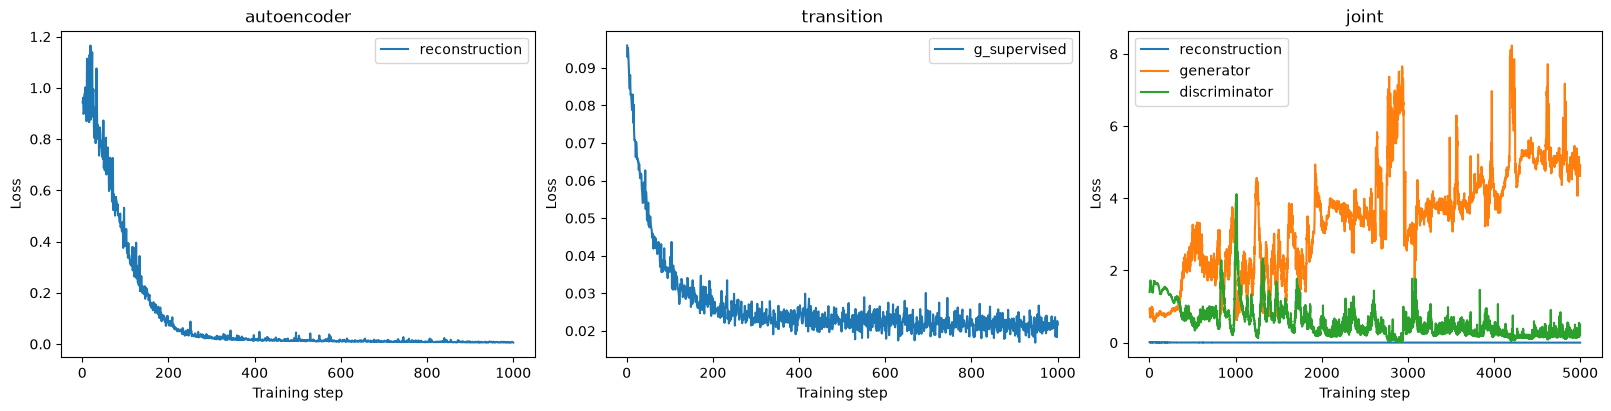

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), layout='constrained')
for ax, stage, losses in zip(axes, ['autoencoder', 'transition', 'joint'], [
    ['reconstruction'], ['g_supervised'], ['reconstruction', 'generator', 'discriminator'],
]):
    rows = history.loc[history['stage'] == stage].set_index('step')
    rows[losses].plot(ax=ax, title=stage, xlabel='Training step', ylabel='Loss')
plt.show()

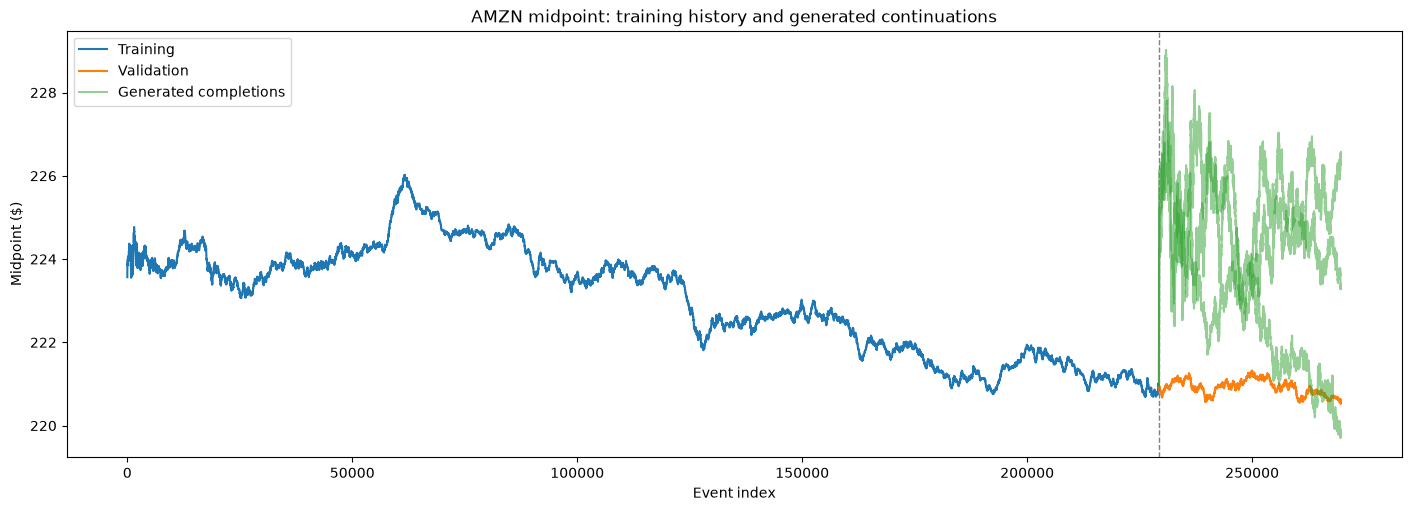

In [11]:
N_COMPLETIONS = 3
horizon = len(test_data)
boundary = len(train_data)
model.eval()
torch.manual_seed(0)
with torch.no_grad():
    context = train_data.features[-config.sequence_length:].unsqueeze(0).to(device)
    h = model.embedder(context)[:, -1].repeat(N_COMPLETIONS, 1)
    paths, _ = generate_wiener_paths(N_COMPLETIONS, horizon + 1, model.generator.noise_dims, device=device)
    # Keep the training noise variance per event when extending the horizon.
    paths *= (horizon / (config.sequence_length - 1)) ** 0.5
    states = []
    for step in range(1, horizon + 1):
        h = model.generator.cell(paths[:, step], h)
        states.append(h)
    completed_features = model.decoder(torch.stack(states, dim=1)).cpu()
completions = [train_data.feature_sequence_to_df(window) for window in completed_features]

def midpoint(book):
    return (book['ASKp1'] + book['BIDp1']) / 20_000

fig, ax = plt.subplots(figsize=(14, 5), layout='constrained')
ax.plot(np.arange(boundary), midpoint(train_data.books), color='tab:blue', label='Training')
ax.plot(np.arange(boundary, boundary + horizon), midpoint(test_data.books),
        color='tab:orange', label='Validation')
events = np.arange(boundary - 1, boundary + horizon)
for index, book in enumerate(completions):
    values = np.r_[midpoint(train_data.books).iloc[-1], midpoint(book)]
    ax.plot(events, values, color='tab:green', alpha=0.5,
            label='Generated completions' if index == 0 else None)
ax.axvline(boundary - 0.5, color='gray', linestyle='--', linewidth=1)
ax.set(title='AMZN midpoint: training history and generated continuations',
       xlabel='Event index', ylabel='Midpoint ($)')
ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.legend()
plt.show()